# Crypto Bull Cycle Analysis
Data source: `data/btc_daily.csv` (pulled via Massive API, in `fetch_data.ipynb`)


- **Section 1**: Bull & Bear Cycle Detection average durations
- **Section 2**: Post-Breakout Drift Test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.signal import argrelextrema

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Load data
df = pd.read_csv('data/btc_daily.csv', parse_dates=['date'])

df.head()

,date,open,high,low,close,volume,vwap,num_trades
0,2013-11-01,203.59999,207.96822,202.90000,202.90000,33.980533,205.1009,117
1,2013-11-02,202.68000,204.24000,201.04000,203.51000,7.055556,202.0084,13
2,2013-11-03,204.66200,209.74800,203.47000,209.74800,9.585259,206.7743,120
3,2013-11-04,209.74800,229.97000,209.40010,226.90010,71.175421,219.7584,484
4,2013-11-05,227.39493,250.14053,222.05236,244.95532,25.221364,237.2967,309


# Section 1 - Bull & Bear Market Cycle Analysis

In [2]:
THRESHOLD = 30 
MIN_DAYS  = 60    
ORDER     = 90    # local extrema window (days each side)

close = df.set_index("date")["close"].sort_index()
vals = close.values
idx = close.index

# 1. Find candidate peaks and troughs
peak_pos   = argrelextrema(vals, np.greater, order=ORDER)[0]
trough_pos = argrelextrema(vals, np.less, order=ORDER)[0]

pts = []
for i in peak_pos: pts.append({"date": idx[i], "price": vals[i], "type": "peak"})
for i in trough_pos: pts.append({"date": idx[i], "price": vals[i], "type": "trough"})
pts.sort(key=lambda x: x["date"])

# 2. Enforce strict alternation — keep highest peak / lowest trough between same-type neighbours
def enforce_alt(points):
    result = [points[0]]
    for pt in points[1:]:
        last = result[-1]
        if pt["type"] == last["type"]:
            if pt["type"] == "peak"   and pt["price"] > last["price"]: result[-1] = pt
            if pt["type"] == "trough" and pt["price"] < last["price"]: result[-1] = pt
        else:
            result.append(pt)
    return result

pts = enforce_alt(pts)

# 3. Build cycles — filter by threshold and minimum duration
cycles = []
for i in range(len(pts) - 1):
    a, b  = pts[i], pts[i+1]
    dur   = (b["date"] - a["date"]).days
    chg   = (b["price"] / a["price"] - 1) * 100
    if a["type"] == "trough" and b["type"] == "peak" and chg >= THRESHOLD and dur >= MIN_DAYS:
        cycles.append({"type": "bull", "start_date": a["date"], "end_date": b["date"],
                       "start_price": a["price"], "end_price": b["price"],
                       "duration_days": dur, "change_pct": chg})
    elif a["type"] == "peak" and b["type"] == "trough" and abs(chg) >= THRESHOLD and dur >= MIN_DAYS:
        cycles.append({"type": "bear", "start_date": a["date"], "end_date": b["date"],
                       "start_price": a["price"], "end_price": b["price"],
                       "duration_days": dur, "change_pct": chg})

cycles_df = pd.DataFrame(cycles)
cycles_df

,type,start_date,end_date,start_price,end_price,duration_days,change_pct
0,bear,2013-11-29,2015-01-14,1165.42500,175.0000,411,-84.984019
1,bull,2015-01-14,2015-07-12,175.00000,310.7575,179,77.575714
2,bull,2015-08-24,2017-12-16,212.70097,19356.9000,845,9000.522673
3,bear,2017-12-16,2018-12-15,19356.90000,3183.0000,364,-83.556251
4,bull,2018-12-15,2019-06-26,3183.00000,12876.0000,193,304.524034
5,bear,2019-06-26,2020-03-12,12876.00000,4857.1000,260,-62.277881
6,bull,2020-03-12,2021-04-13,4857.10000,63587.2000,397,1209.159787
7,bear,2021-04-13,2021-07-20,63587.20000,29796.1600,98,-53.141261
8,bull,2021-07-20,2021-11-08,29796.16000,67554.8400,111,126.723309
9,bear,2021-11-08,2022-11-21,67554.84000,15760.1400,378,-76.670598


### Average cycle durations

In [3]:
# average durations
avg = cycles_df.groupby("type")["duration_days"].agg(["mean", "count"]).rename(
    columns={"mean": "avg_duration_days", "count": "num_cycles"})
avg["avg_duration_months"] = (avg["avg_duration_days"] / 30.44).round(1)
display(avg.round(1))

,avg_duration_days,num_cycles,avg_duration_months
type,,,
bear,272.2,6,8.9
bull,290.6,9,9.5


### Bear Market Cycles

In [4]:
bears = cycles_df[cycles_df["type"] == "bear"].copy().reset_index(drop=True)
bears["peak_date"] = bears["start_date"].dt.strftime("%Y-%m-%d")
bears["trough_date"] = bears["end_date"].dt.strftime("%Y-%m-%d")
bears["peak_price"] = bears["start_price"].round(0).astype(int)
bears["trough_price"] = bears["end_price"].round(0).astype(int)
bears["drawdown"] = bears["change_pct"].round(1).astype(str) + "%"
bears["label"] = bears["start_date"].dt.year.astype(str) + "-" + bears["end_date"].dt.year.astype(str)

display(bears[["label", "peak_date", "trough_date", "peak_price", "trough_price", "drawdown", "duration_days"]])

,label,peak_date,trough_date,peak_price,trough_price,drawdown,duration_days
0,2013-2015,2013-11-29,2015-01-14,1165,175,-85.0%,411
1,2017-2018,2017-12-16,2018-12-15,19357,3183,-83.6%,364
2,2019-2020,2019-06-26,2020-03-12,12876,4857,-62.3%,260
3,2021-2021,2021-04-13,2021-07-20,63587,29796,-53.1%,98
4,2021-2022,2021-11-08,2022-11-21,67555,15760,-76.7%,378
5,2025-2026,2025-10-06,2026-02-05,124720,62791,-49.7%,122


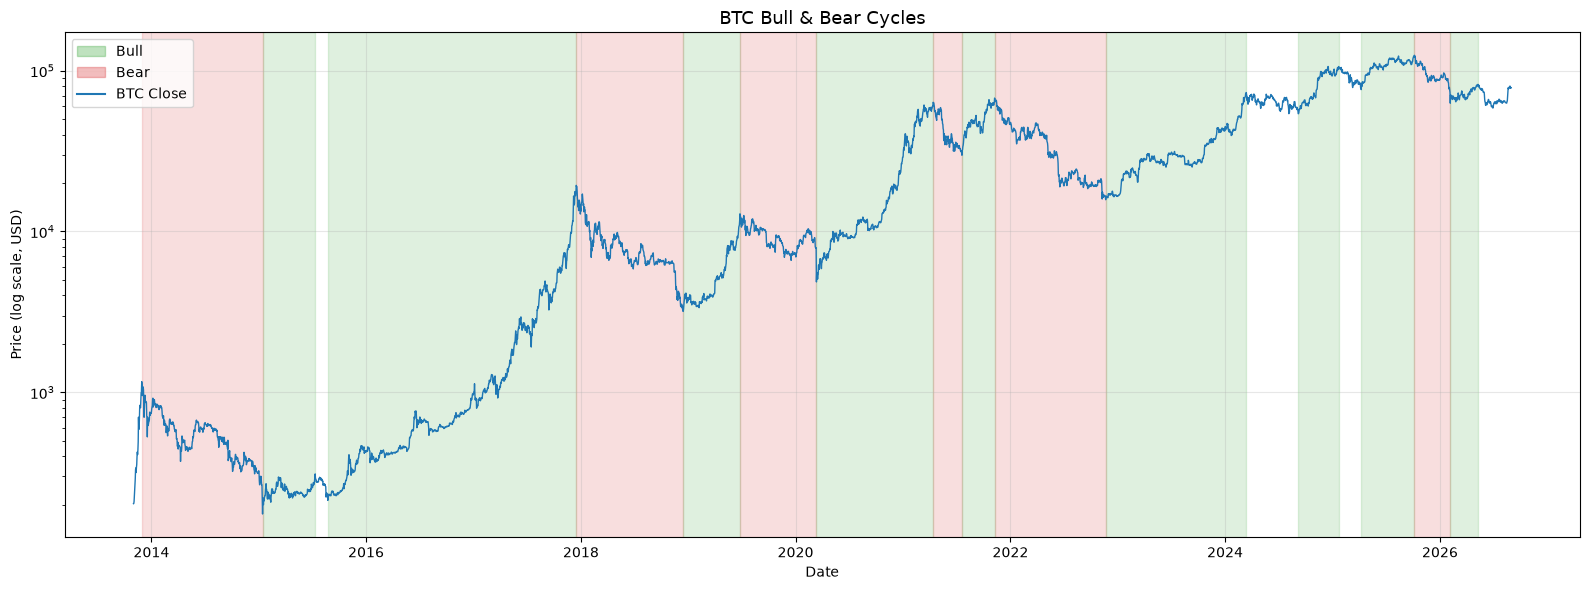

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.semilogy(close.index, close.values, color="#1f77b4", linewidth=1, label="BTC Close")

for _, row in cycles_df.iterrows():
    color = "#d62728" if row["type"] == "bear" else "#2ca02c"
    ax.axvspan(row["start_date"], row["end_date"], color=color, alpha=0.15)


bull_patch = mpatches.Patch(color="#2ca02c", alpha=0.3, label="Bull")
bear_patch = mpatches.Patch(color="#d62728", alpha=0.3, label="Bear")
ax.legend(handles=[bull_patch, bear_patch,
                   plt.Line2D([0],[0], color="#1f77b4", label="BTC Close")])
ax.set_title("BTC Bull & Bear Cycles", fontsize=13)
ax.set_ylabel("Price (log scale, USD)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

# Section 2 - Post-Breakout Drift Test
Test whether BTC exhibits positive forward returns following a >+5σ weekly return,
where σ is estimated from the preceding 60-day realised volatility (annualised) scaled to a weekly horizon.

All weeks with a >5σ signal, regardless of trend.

In [6]:
log_ret = np.log(close / close.shift(1))
vol_annual = log_ret.rolling(60).std() * np.sqrt(252)   # 60-day annualised log-vol
ema200 = close.ewm(span=200, adjust=False).mean()

weekly_close   = close.resample("W").last()
weekly_ret_log = np.log(weekly_close / weekly_close.shift(1))  # log weekly return
weekly_vol_ann = vol_annual.resample("W").last().shift(1) # prior week annualised vol
weekly_vol_wk  = weekly_vol_ann / np.sqrt(52)

signal = weekly_ret_log / weekly_vol_wk

sig5 = signal[signal > 5].dropna().copy()
result = pd.DataFrame({
    "weekly_ret_log_%": weekly_ret_log[sig5.index].mul(100).round(2),
    "ann_vol_%"       : weekly_vol_ann[sig5.index].mul(100).round(2),
    "weekly_vol_%"    : weekly_vol_wk[sig5.index].mul(100).round(2),
    "signal_sigma"    : sig5.round(2)
})
result.index = result.index.strftime("%Y-%m-%d")
display(result)

,weekly_ret_log_%,ann_vol_%,weekly_vol_%,signal_sigma
date,,,,
2016-05-29,17.09,22.34,3.10,5.52
2026-08-23,21.27,23.37,3.24,6.56


Subset above the 200-day EMA - measure returns at 30D, 60D, 120D, 365D. Either above the 200-day EMA this week, or breaks above it the next week.

In [7]:
weekly_ema200  = ema200.resample("W").last()
next_close     = weekly_close.shift(-1)
next_ema200    = weekly_ema200.shift(-1)

above_now  = weekly_close[sig5.index] > weekly_ema200[sig5.index]
breaks_next = (weekly_close[sig5.index] <= weekly_ema200[sig5.index]) & \
              (next_close[sig5.index] > next_ema200[sig5.index])
sig5_ema   = sig5[above_now | breaks_next]

HORIZONS = [30, 60, 120, 365]
rows = []
for date in sig5_ema.index:
    ts  = pd.Timestamp(date)
    row = {"date": ts, "signal_sigma": round(signal[date], 2),
           "weekly_ret_log_%": round(weekly_ret_log[date]*100, 2)}
    ref = close.loc[:ts].iloc[-1]
    for h in HORIZONS:
        target = ts + pd.Timedelta(days=h)
        if target <= close.index[-1]:
            row[f"fwd_{h}d_%"] = round((close.loc[:target].iloc[-1] / ref - 1) * 100, 2)
        else:
            row[f"fwd_{h}d_%"] = np.nan
    rows.append(row)

fwd_df = pd.DataFrame(rows).set_index("date")
fwd_df.index = fwd_df.index.strftime("%Y-%m-%d")
display(fwd_df)


,signal_sigma,weekly_ret_log_%,fwd_30d_%,fwd_60d_%,fwd_120d_%,fwd_365d_%
date,,,,,,
2016-05-29,5.52,17.09,25.11,26.42,17.34,339.22
2026-08-23,6.56,21.27,NaN,NaN,NaN,NaN


Using 4 sigma instead

In [8]:
log_ret = np.log(close / close.shift(1))
vol_annual = log_ret.rolling(60).std() * np.sqrt(252)   # 60-day annualised log-vol
ema200 = close.ewm(span=200, adjust=False).mean()

weekly_close   = close.resample("W").last()
weekly_ret_log = np.log(weekly_close / weekly_close.shift(1))  # log weekly return
weekly_vol_ann = vol_annual.resample("W").last().shift(1) # prior week annualised vol
weekly_vol_wk  = weekly_vol_ann / np.sqrt(52)

signal = weekly_ret_log / weekly_vol_wk

sig5 = signal[signal > 4].dropna().copy()
result = pd.DataFrame({
    "weekly_ret_log_%": weekly_ret_log[sig5.index].mul(100).round(2),
    "ann_vol_%"       : weekly_vol_ann[sig5.index].mul(100).round(2),
    "weekly_vol_%"    : weekly_vol_wk[sig5.index].mul(100).round(2),
    "signal_sigma"    : sig5.round(2)
})
result.index = result.index.strftime("%Y-%m-%d")
display(result)

,weekly_ret_log_%,ann_vol_%,weekly_vol_%,signal_sigma
date,,,,
2016-05-29,17.09,22.34,3.10,5.52
2019-04-07,23.11,39.34,5.46,4.24
2023-01-15,19.82,32.21,4.47,4.44
2026-08-23,21.27,23.37,3.24,6.56


In [9]:
weekly_ema200  = ema200.resample("W").last()
next_close     = weekly_close.shift(-1)
next_ema200    = weekly_ema200.shift(-1)

above_now  = weekly_close[sig5.index] > weekly_ema200[sig5.index]
breaks_next = (weekly_close[sig5.index] <= weekly_ema200[sig5.index]) & \
              (next_close[sig5.index] > next_ema200[sig5.index])
sig4_ema   = sig5[above_now | breaks_next]

HORIZONS = [30, 60, 120, 365]
rows = []
for date in sig4_ema.index:
    ts  = pd.Timestamp(date)
    row = {"date": ts, "signal_sigma": round(signal[date], 2),
           "weekly_ret_log_%": round(weekly_ret_log[date]*100, 2)}
    ref = close.loc[:ts].iloc[-1]
    for h in HORIZONS:
        target = ts + pd.Timedelta(days=h)
        if target <= close.index[-1]:
            row[f"fwd_{h}d_%"] = round((close.loc[:target].iloc[-1] / ref - 1) * 100, 2)
        else:
            row[f"fwd_{h}d_%"] = np.nan
    rows.append(row)

fwd_df = pd.DataFrame(rows).set_index("date")
fwd_df.index = fwd_df.index.strftime("%Y-%m-%d")
display(fwd_df)


,signal_sigma,weekly_ret_log_%,fwd_30d_%,fwd_60d_%,fwd_120d_%,fwd_365d_%
date,,,,,,
2016-05-29,5.52,17.09,25.11,26.42,17.34,339.22
2019-04-07,4.24,23.11,11.18,50.96,128.23,41.73
2023-01-15,4.44,19.82,6.35,19.98,30.13,103.64
2026-08-23,6.56,21.27,NaN,NaN,NaN,NaN


### Max drawdown analysis

Some brief analysis:
- For the 2019 bull cycle, there is a huge divergence between MDD 365d (-62%) and MDD to bull end (-13%). The 365-day window extends deep into the next bear market (BTC crashed from Jun 2019 to Mar 2020). The MDD-to-bull-end shows the bull itself was actually well-behaved. So, this is a strong case for using "to bull end" as the right horizon rather than a fixed 365 days.
- Note that the 2026 dates were excluded

In [10]:
# max drawdown analysis for each breakout event
def max_drawdown(prices):
    """Max peak-to-trough drawdown within a price series."""
    if len(prices) < 2:
        return np.nan
    rolling_peak = prices.expanding().max()
    dd = (prices - rolling_peak) / rolling_peak
    return round(dd.min() * 100, 2)  # return as %

# extract peak dates from Section 1 cycle detection
peak_dates = sorted([p["date"] for p in pts if p["type"] == "peak"])

def next_peak_after(date):
    """Return the next bull market peak after a given date."""
    future = [p for p in peak_dates if p > date]
    return future[0] if future else None

HORIZONS = [30, 60, 120, 365]
rows = []
for date in sig4_ema.index[:-1]:
    ts  = pd.Timestamp(date)
    ref = close.loc[:ts].iloc[-1]
    row = {"date": ts, "signal_sigma": round(signal[date], 2)}

    # fixed horizon MDD
    for h in HORIZONS:
        end = ts + pd.Timedelta(days=h)
        if end > close.index[-1]:
            row[f"mdd_{h}d_%"] = np.nan
        else:
            window = close.loc[ts:end]
            row[f"mdd_{h}d_%"] = max_drawdown(window)

    # MDD to end of bull
    peak = next_peak_after(ts)
    if peak is None or peak > close.index[-1]:
        row["mdd_to_bull_end_%"] = np.nan
        row["bull_end_date"] = str(peak.date()) if peak else "—"
    else:
        window = close.loc[ts:peak]
        row["mdd_to_bull_end_%"] = max_drawdown(window)
        row["bull_end_date"] = str(peak.date())

    rows.append(row)

mdd_df = pd.DataFrame(rows).set_index("date")
mdd_df.index = mdd_df.index.strftime("%Y-%m-%d")
display(mdd_df)


,signal_sigma,mdd_30d_%,mdd_60d_%,mdd_120d_%,mdd_365d_%,mdd_to_bull_end_%,bull_end_date
date,,,,,,,
2016-05-29,5.52,-21.37,-21.37,-29.46,-29.60,-35.01,2017-12-16
2019-04-07,4.24,-7.42,-12.30,-26.65,-62.28,-12.97,2019-06-26
2023-01-15,4.44,-8.91,-18.57,-18.57,-20.08,-20.08,2024-03-13


In [13]:
# Return-to-MDD ratio: terminal forward return / |max drawdown| at each horizon
#
# For a given window (e.g. 60 days):
#   - terminal return: (price at day 60 / entry price) - 1
#   - MDD: worst peak-to-trough drop that occurred anywhere inside those 60 days
#   - ratio = terminal return / |MDD|
#
# Ratio > 1 : return exceeded the worst drawdown (good risk/reward)
# Ratio < 1 : drawdown was larger than the terminal gain (bumpy ride for little reward at that horizon)
#
# Depends on: max_drawdown(), next_peak_after(), peak_dates (defined in s2-mdd)

HORIZONS = [30, 60, 120, 365]
rows = []

for date in sig4_ema.index:
    ts  = pd.Timestamp(date)
    ref = close.loc[:ts].iloc[-1]
    row = {"date": ts, "signal": round(signal[date], 2)}

    for h in HORIZONS:
        end = ts + pd.Timedelta(days=h)
        if end > close.index[-1]:
            row[f"ratio_{h}d"] = np.nan
        else:
            window  = close.loc[ts:end]
            fwd_ret = (window.iloc[-1] / ref - 1) * 100
            mdd     = max_drawdown(window)  # negative %
            row[f"ratio_{h}d"] = round(fwd_ret / abs(mdd), 2) if mdd != 0 else np.nan

    # Bull-end ratio: return to cycle peak / MDD from entry to cycle peak
    peak = next_peak_after(ts)
    if peak is None or peak > close.index[-1]:
        row["ratio_bull_end"] = np.nan
        row["bull_end_date"]  = str(peak.date()) if peak else "—"
    else:
        window  = close.loc[ts:peak]
        fwd_ret = (window.iloc[-1] / ref - 1) * 100
        mdd     = max_drawdown(window)
        row["ratio_bull_end"] = round(fwd_ret / abs(mdd), 2) if mdd != 0 else np.nan
        row["bull_end_date"]  = str(peak.date())

    rows.append(row)

ratio_df = pd.DataFrame(rows).set_index("date")
ratio_df.index = ratio_df.index.strftime("%Y-%m-%d")
print("Return / |MDD| ratio — values < 1 mean drawdown exceeded terminal return at that horizon")
display(ratio_df)


Return / |MDD| ratio — values < 1 mean drawdown exceeded terminal return at that horizon


,signal,ratio_30d,ratio_60d,ratio_120d,ratio_365d,ratio_bull_end,bull_end_date
date,,,,,,,
2016-05-29,5.52,1.18,1.24,0.59,11.46,103.68,2017-12-16
2019-04-07,4.24,1.51,4.14,4.81,0.67,11.49,2019-06-26
2023-01-15,4.44,0.71,1.08,1.62,5.16,12.46,2024-03-13
